<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Machine%20Learning/Projetos/Departamento%20Prod%20e%20Manu/Departamento_de_produ%C3%A7%C3%A3o_de_manuten%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Departamento de produção

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from skimage import io
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from tensorflow.keras.layers import Dense, Input, AveragePooling2D, Flatten, Dropout, MaxPool2D
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, UpSampling2D, Concatenate
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
all_images_df = pd.read_csv("/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção/defect_and_no_defect.csv")
all_images_df.head()

,ImageID,label
0,0002cc93b.jpg,1
1,0007a71bf.jpg,1
2,000a4bcdd.jpg,1
3,000f6bf48.jpg,1
4,0014fce06.jpg,1


In [4]:
all_images_df.shape

(12997, 2)

In [5]:
defect_class_mas_df = pd.read_csv("/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção/train.csv")

In [6]:
defect_class_mas_df.shape

(5748, 3)

In [7]:
defect_class_mas_df.head()

,ImageId,ClassId,EncodedPixels
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...


In [8]:
(defect_class_mas_df.shape[0] /  all_images_df.shape[0]) * 100

44.22559052088943

In [9]:
defect_class_mas_df["ClassId"].unique()

array([1, 3, 4, 2])

## Exploração e visualização dos dados

In [10]:
all_images_df["label"].value_counts()

,count
label,
1,7095
0,5902


Text(0.5, 1.0, 'Defeitos e não defeitos')

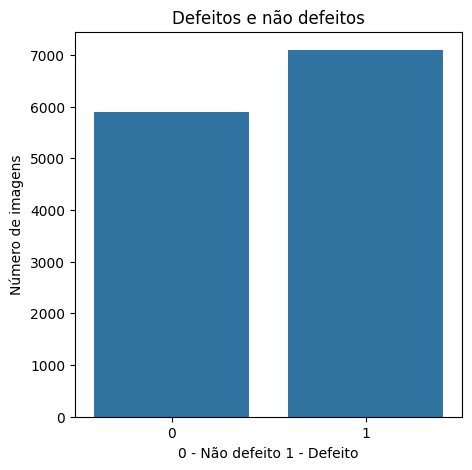

In [16]:
plt.figure(figsize = (5, 5))
sns.barplot(x = all_images_df["label"].value_counts().index, y = all_images_df["label"].value_counts())
plt.ylabel("Número de imagens")
plt.xlabel("0 - Não defeito 1 - Defeito")
plt.title("Defeitos e não defeitos")

Text(0.5, 1.0, 'Número de imagens por class de defeito')

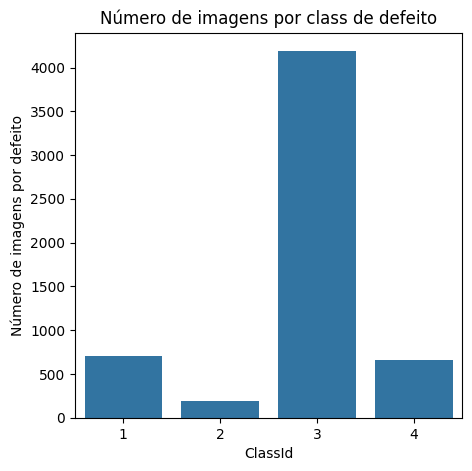

In [19]:
plt.figure(figsize = (5, 5))
sns.countplot(x = defect_class_mas_df["ClassId"])
plt.ylabel("Número de imagens por defeito")
plt.xlabel("ClassId")
plt.title("Número de imagens por class de defeito")

In [21]:
defect_class_mas_df["mask"] = defect_class_mas_df["ClassId"].map(lambda x: 1)

In [22]:
defect_class_mas_df.head()

,ImageId,ClassId,EncodedPixels,mask
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...,1
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...,1
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...,1
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...,1
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...,1


In [23]:
defect_type = defect_class_mas_df.groupby(["ImageId"])["mask"].sum()
defect_type

,mask
ImageId,
0002cc93b.jpg,1
0007a71bf.jpg,1
000a4bcdd.jpg,1
000f6bf48.jpg,1
0014fce06.jpg,1
...,...
ffcf72ecf.jpg,1
fff02e9c5.jpg,1
fffe98443.jpg,1


In [25]:
defect_type.value_counts()

,count
mask,
1,5201
2,272
3,1


Text(0.5, 1.0, 'Número de defeitos nas imagens')

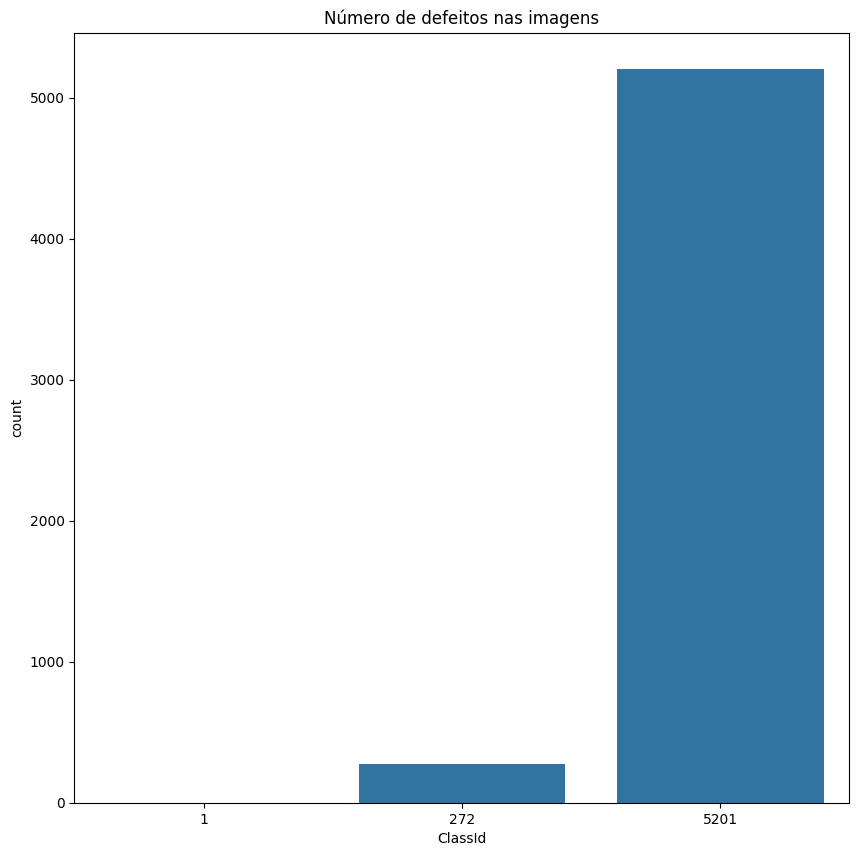

In [26]:
plt.figure(figsize = (10, 10))
sns.barplot(x = defect_type.value_counts(), y = defect_type.value_counts())
plt.xlabel("ClassId")
plt.title("Número de defeitos nas imagens")

In [27]:
train_dir = "/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção/train_images"

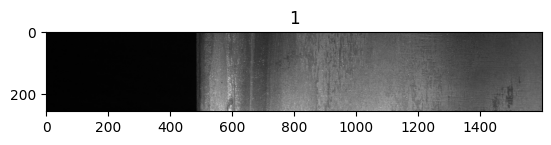

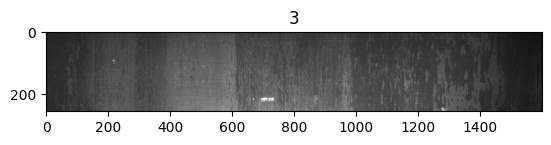

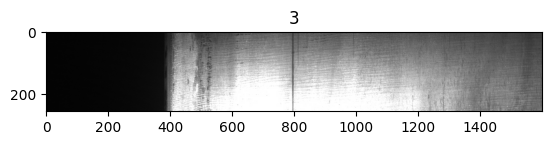

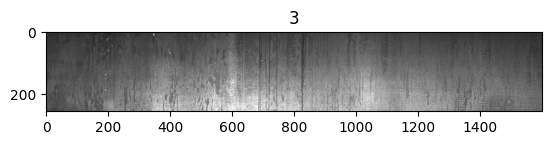

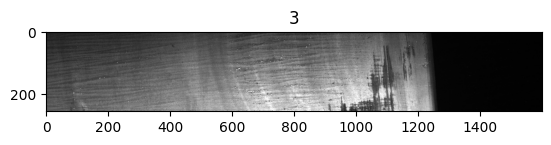

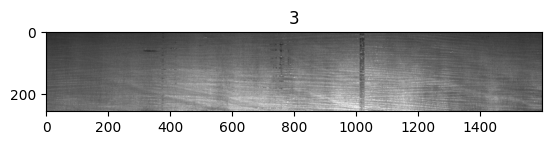

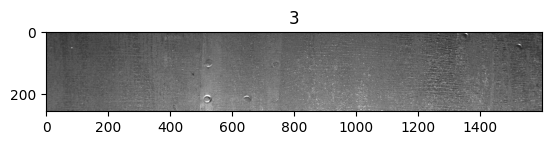

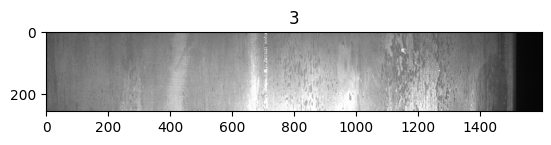

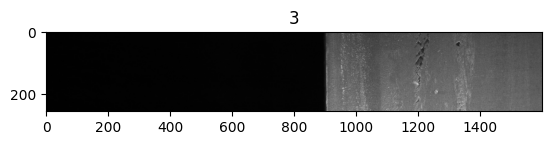

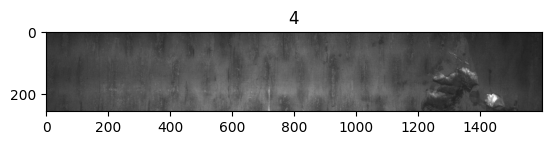

In [28]:
for i in range(10):
  img = io.imread(os.path.join(train_dir, defect_class_mas_df["ImageId"][i]))
  plt.figure()
  plt.title(defect_class_mas_df["ClassId"][i])
  plt.imshow(img)

In [29]:
cd /content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção

/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção


In [32]:
from utilities import rle2mask

In [33]:
defect_class_mas_df

,ImageId,ClassId,EncodedPixels,mask
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...,1
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...,1
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...,1
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...,1
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...,1
...,...,...,...,...
5743,c12842f5e.jpg,3,88 23 342 29 596 34 850 39 1105 44 1361 46 161...,1
5744,2222a03b3.jpg,3,63332 4 63587 11 63841 20 64096 27 64351 35 64...,1
5745,b43ea2c01.jpg,1,185024 7 185279 11 185535 12 185790 13 186045 ...,1
5746,1bc37a6f4.jpg,3,303867 1 304122 3 304376 6 304613 3 304630 9 3...,1


In [35]:
image_index = 20
mask = rle2mask(defect_class_mas_df["EncodedPixels"][image_index], img.shape[0], img.shape[1])

In [36]:
mask.shape

(256, 1600)

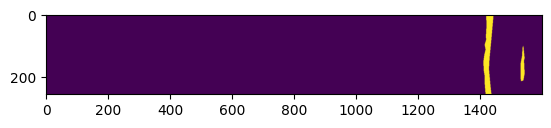

In [37]:
plt.imshow(mask)

(256, 1600, 3)

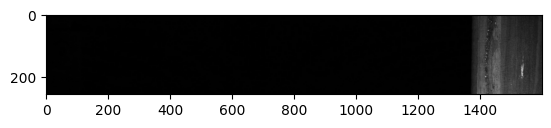

In [38]:
img = io.imread(os.path.join(train_dir, defect_class_mas_df["ImageId"][image_index]))
plt.imshow(img)
img.shape

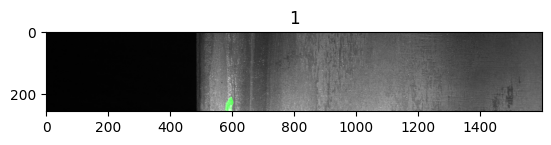

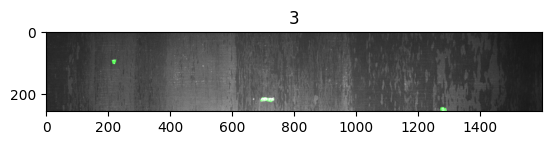

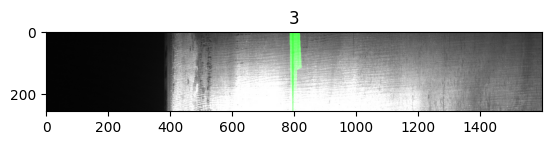

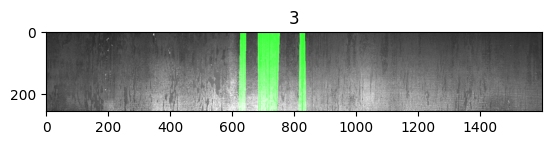

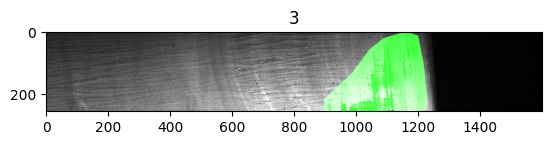

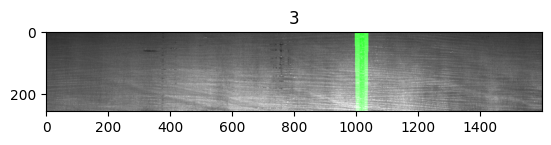

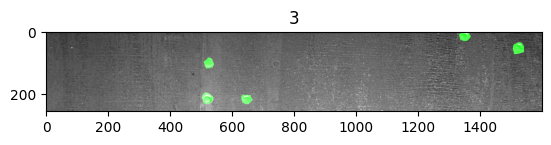

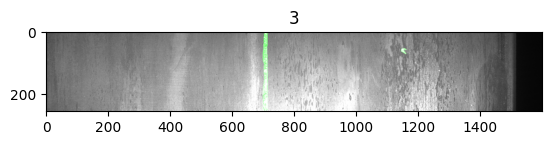

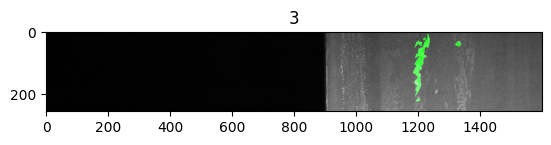

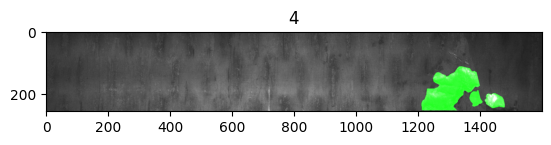

In [39]:
for i in range(10):
  img = io.imread(os.path.join(train_dir, defect_class_mas_df["ImageId"][i]))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  mask = rle2mask(defect_class_mas_df["EncodedPixels"][i], img.shape[0], img.shape[1])

  img[mask == 1, 1] = 255
  plt.figure()
  plt.imshow(img)
  plt.title(defect_class_mas_df["ClassId"][i])

## Rede neural para prever se existe defeito em uma imagem

In [89]:
!pip install keras-preprocessing

In [40]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(all_images_df, test_size = 0.15)

In [47]:
from keras_preprocessing.image import ImageDataGenerator

In [48]:
datagen = ImageDataGenerator(rescale = 1./255, validation_split = 0.15)

In [ ]:
train_generator = datagen.flow_from_dataframe(dataframe = train, directory = train_dir,
                                              x_col = "ImageID", y_col = "label",
                                              subset = "training", batch_size = 16,
                                              shuffle = True, class_mode = "other",
                                              target_size = (256, 256))

In [ ]:
valid_generator = datagen.flow_from_dataframe(dataframe = train, directory = train_dir,
                                              x_col = "ImageID", y_col = "label",
                                              subset = "validation", batch_size = 16,
                                              shuffle = True, class_mode = "other",
                                              target_size = (256, 256))

In [52]:
test_datagen = ImageDataGenerator(rescale = 1./255.)
test_generator = test_datagen.flow_from_dataframe(dataframe = test, directory= train_dir,
                                                  x_col = "ImageID", y_col = None,
                                                  batch_size = 16, shuffle = False,
                                                  class_mode = None, target_size= (256, 256))

Found 1950 validated image filenames.


In [53]:
basemodel = ResNet50(weights="imagenet", include_top= False, input_tensor = Input(shape = (256, 256, 3)))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [54]:
basemodel.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
for layer in basemodel.layers:
  layers.trainable = False

In [55]:
headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size = (4, 4))(headmodel)
headmodel = Flatten()(headmodel)
headmodel = Dense(256, activation = "relu")(headmodel)
headmodel = Dropout(0.3)(headmodel)
headmodel = Dense(1, activation = "sigmoid")(headmodel)

In [56]:
model = Model(inputs = basemodel.input, outputs = headmodel)

In [ ]:
model.summary()

In [58]:
model.compile(loss = "binary_crossentropy", optimizer = "Nadam", metrics = ["accuracy"])

In [64]:
earlystopping = EarlyStopping(monitor = "val_loss", mode="min", patience = 20)

In [65]:
checkpointer = ModelCheckpoint(filepath = "weights.keras", save_best_only = True)

In [ ]:
# Vai demorar cerca de 2h para treinar
history = model.fit(train_generator, epochs = 40, validation_data = valid_generator, callbacks = [checkpointer, earlystopping])

In [ ]:
model_json = model.to_json()
with open("resnet-classifier-model.json", "w") as json_file:
  json_file.write(model_json)

# Avaliação da ResNet

## ESSA ETAPA SO È NECESSARIO CASO NÂO EFETUE O TREINAMENTO NAS 2 LINHAS ANTERIORES

In [77]:
from tensorflow.keras.models import model_from_json

# Método 1: Tentar carregar com custom_objects
try:
    custom_objects = {
        'Functional': tf.keras.Model,
        'HeNormal': tf.keras.initializers.HeNormal(),
        'Nadam': tf.keras.optimizers.Nadam
    }

    with open("/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção/resnet-classifier-model.json", "r") as json_file:
        json_save_model = json_file.read()

    model = model_from_json(json_save_model, custom_objects=custom_objects)
    model.load_weights("/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção/weights.hdf5")
    model.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])

    print("Modelo carregado com sucesso!")

except Exception as e:
    print(f"Erro no Método 1: {e}")

    try:
        model = tf.keras.models.load_model("/content/drive/MyDrive/Ciência de Dados para Empresas e Negócios/Departamento de manutenção/resunet-segmentation-model.h5")
        print("Modelo carregado via .h5 com sucesso!")
    except:
        print("Arquivo .h5 não encontrado")

Modelo carregado com sucesso!


In [78]:
test_predict = model.predict(test_generator, verbose = True)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


122/122 ━━━━━━━━━━━━━━━━━━━━ 652s 5s/step


In [80]:
predict = []
for i in test_predict:
  if i < 0.01:
    predict.append(0)
  else:
    predict.append(1)
predict = np.asarray(predict)

In [81]:
len(predict)

1950

In [82]:
predict

array([1, 0, 1, ..., 1, 0, 1])

In [83]:
test.label

,label
1658,1
12640,0
3527,1
5740,1
8075,0
...,...
6249,1
11499,0
1784,1
11197,0


In [84]:
original = np.asarray(test.label)
len(original)

1950

In [85]:
from sklearn.metrics import accuracy_score
accuracy_score(original, predict)

0.8876923076923077

In [86]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(original, predict)
cm

array([[ 686,  216],
       [   3, 1045]])

<Axes: >

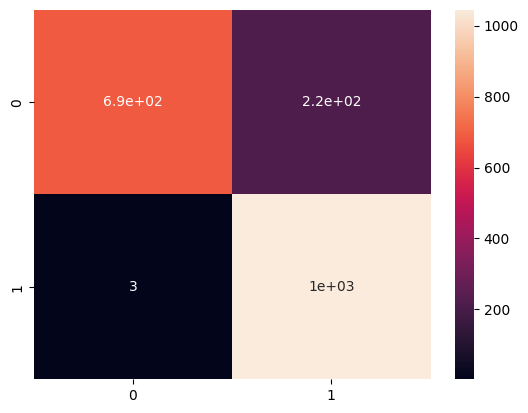

In [87]:
sns.heatmap(cm, annot = True)

In [88]:
from sklearn.metrics import classification_report
print(classification_report(original, predict))

              precision    recall  f1-score   support

           0       1.00      0.76      0.86       902
           1       0.83      1.00      0.91      1048

    accuracy                           0.89      1950
   macro avg       0.91      0.88      0.88      1950
weighted avg       0.91      0.89      0.89      1950

